# AI-Based Medical Diagnosis Assistant — Model Training Notebook

Trains a symptom-to-disease classifier from `dataset.csv`.

Pipeline:
1. Load & clean the raw CSV (whitespace, duplicates, NaNs)
2. Convert wide symptom columns → dense binary symptom matrix
3. Train Random Forest, Decision Tree, and Naive Bayes
4. Evaluate each with classification report + confusion matrix
5. Export the best model + the feature column list for the backend team


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
)

RANDOM_STATE = 42

## 1. Load & Clean the Raw Data

In [3]:
# --- Load ---
df = pd.read_csv(r"../data/dataset.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# --- Strip whitespace from every string cell (values AND column names) ---
# The dataset is known to have inconsistent spacing, e.g. " skin_rash" vs "skin_rash".
df.columns = df.columns.str.strip()

symptom_cols_raw = [c for c in df.columns if c.startswith("Symptom_")]

# Strip whitespace in-place for the Disease column and all Symptom_N columns.
# Non-string / NaN cells are left untouched (NaN stays NaN).
for col in ["Disease"] + symptom_cols_raw:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Replace any now-empty strings (e.g. cells that were only whitespace) with true NaN
df[symptom_cols_raw] = df[symptom_cols_raw].replace("", np.nan)

print("Unique diseases:", df["Disease"].nunique())

Unique diseases: 41


In [5]:
# --- Drop exact duplicate rows ---
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} duplicate rows ({before} -> {after})")

Dropped 4616 duplicate rows (4920 -> 304)


## 2. Wide → Binary Symptom Matrix

Each patient row lists between 1 and 17 symptoms across `Symptom_1..Symptom_17`,
with unused slots as `NaN`. We convert this into a dense binary matrix where every
unique symptom in the dataset becomes its own `symptom_<name>` column.

In [6]:
# --- Discover every unique symptom across all 17 columns ---
all_symptoms = set()
for col in symptom_cols_raw:
    all_symptoms.update(df[col].dropna().unique())

all_symptoms = sorted(all_symptoms)
print(f"Found {len(all_symptoms)} unique symptoms")
print(all_symptoms[:10], "...")

Found 131 unique symptoms
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort'] ...


In [7]:
# --- Build the binary matrix ---
# For each row, gather the set of symptoms present (ignoring NaNs), then
# one-hot them against the full symptom vocabulary.

def row_symptom_set(row):
    return {row[c] for c in symptom_cols_raw if pd.notna(row[c])}

symptom_sets = df.apply(row_symptom_set, axis=1)

# symptom_columns is the canonical, ordered list of binary feature names.
# This exact list (and order) must be saved and reused at inference time.
symptom_columns = [f"symptom_{s}" for s in all_symptoms]

binary_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=symptom_columns,
    dtype=np.int8,
)

for idx, present_symptoms in symptom_sets.items():
    for s in present_symptoms:
        binary_matrix.at[idx, f"symptom_{s}"] = 1

print("Binary matrix shape:", binary_matrix.shape)
binary_matrix.head()

Binary matrix shape: (304, 131)


,symptom_abdominal_pain,symptom_abnormal_menstruation,symptom_acidity,symptom_acute_liver_failure,symptom_altered_sensorium,symptom_anxiety,symptom_back_pain,symptom_belly_pain,symptom_blackheads,symptom_bladder_discomfort,...,symptom_vomiting,symptom_watering_from_eyes,symptom_weakness_in_limbs,symptom_weakness_of_one_body_side,symptom_weight_gain,symptom_weight_loss,symptom_yellow_crust_ooze,symptom_yellow_urine,symptom_yellowing_of_eyes,symptom_yellowish_skin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# --- Assemble final modeling dataframe ---
X = binary_matrix
y = df["Disease"]

# Encode disease labels to integers for sklearn (kept invertible via label_encoder)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("X shape:", X.shape)
print("Number of disease classes:", len(label_encoder.classes_))

X shape: (304, 131)
Number of disease classes: 41


## 3. Train / Test Split (80/20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (243, 131)
Test shape: (61, 131)


## 4. Train the Three Candidate Models

In [10]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": BernoulliNB(),  # BernoulliNB is the right fit for binary 0/1 features
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Random Forest
Trained: Decision Tree
Trained: Naive Bayes


## 5. Evaluation — Classification Report & Confusion Matrix

In [11]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    # macro recall: treats every disease class equally, important since some
    # diseases are rarer than others and missing them matters a lot in medicine
    rec = recall_score(y_test, y_pred, average="macro")

    results[name] = {"accuracy": acc, "macro_recall": rec, "model": model}

    print("=" * 70)
    print(f"{name}  |  Accuracy: {acc:.4f}  |  Macro Recall: {rec:.4f}")
    print("=" * 70)
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

Random Forest  |  Accuracy: 1.0000  |  Macro Recall: 1.0000
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.

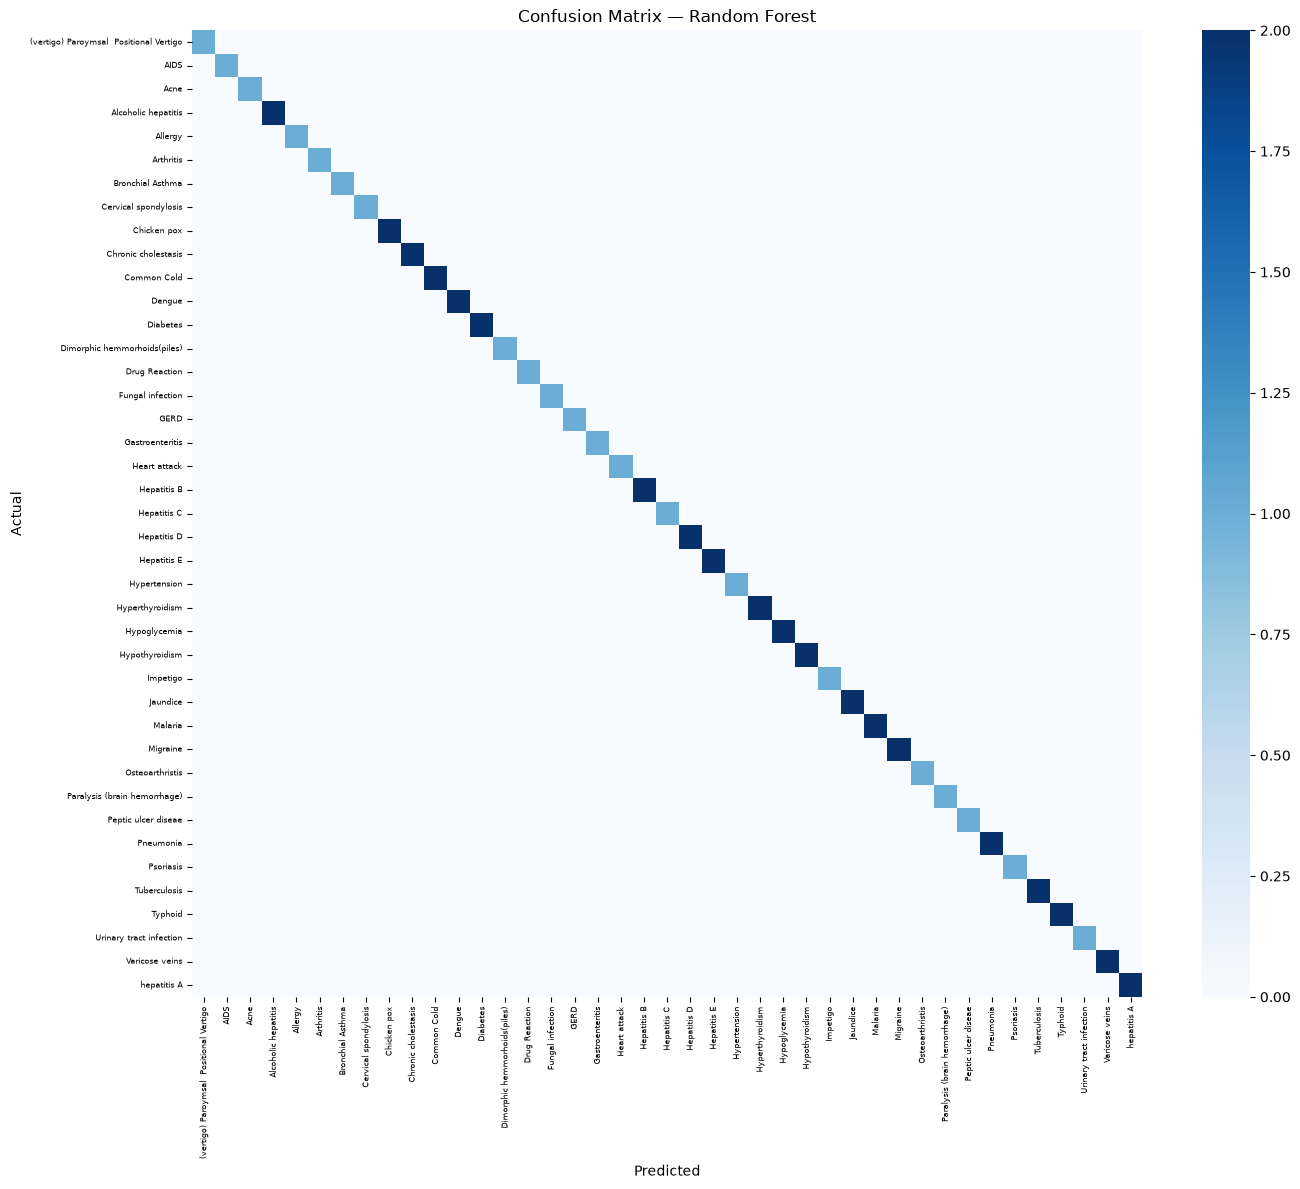

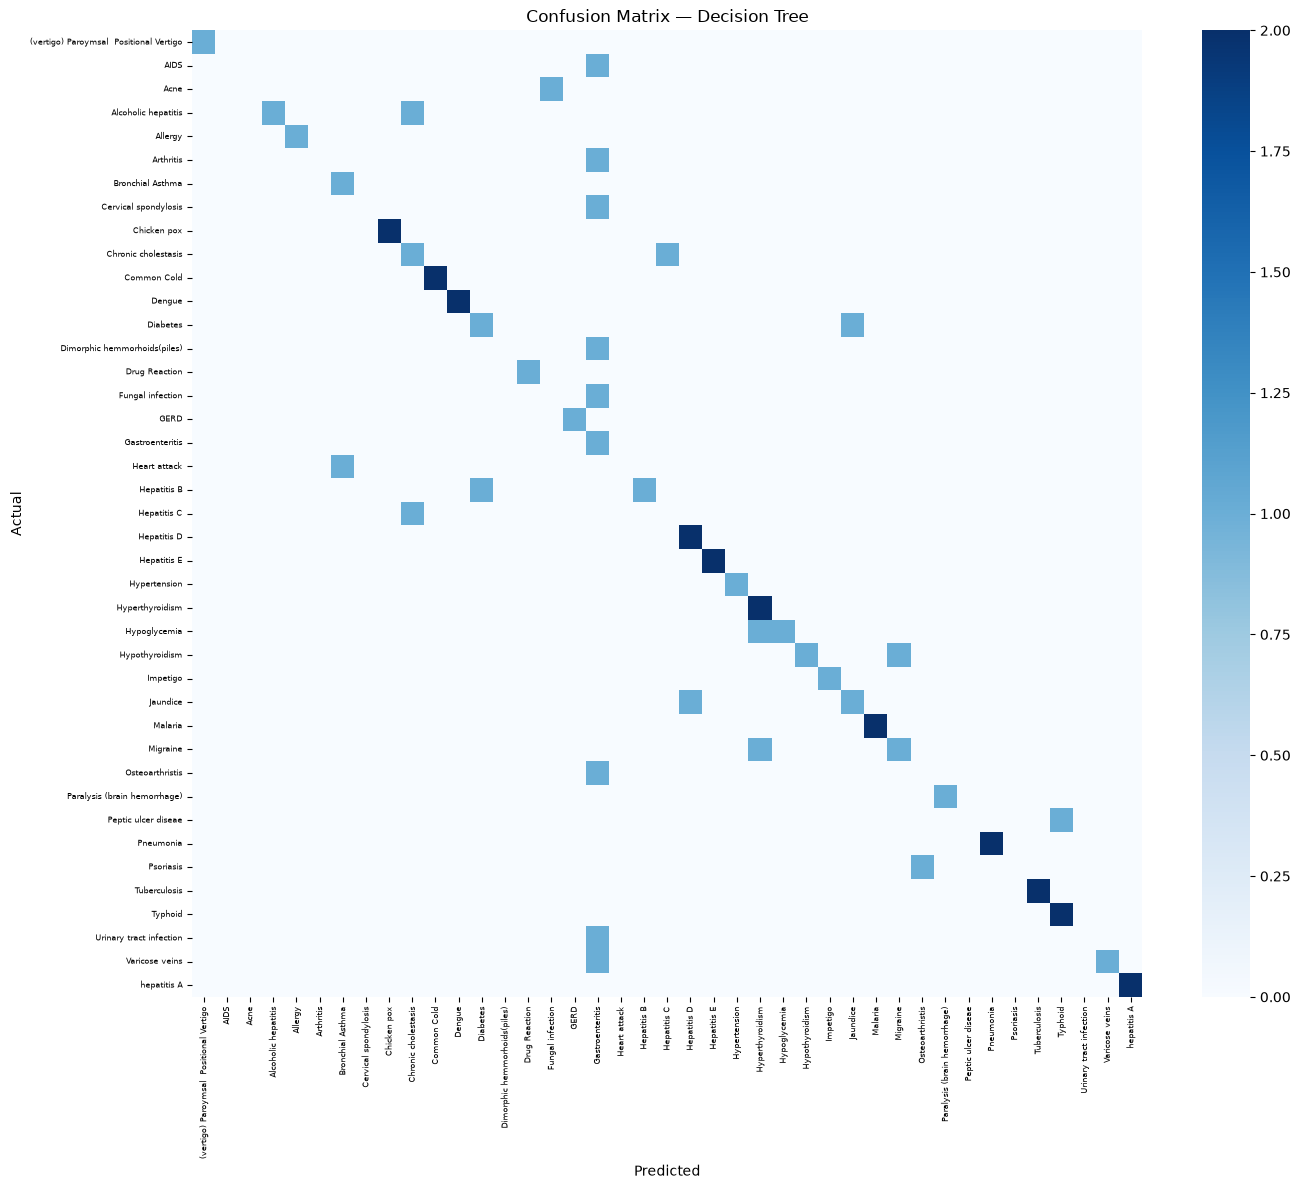

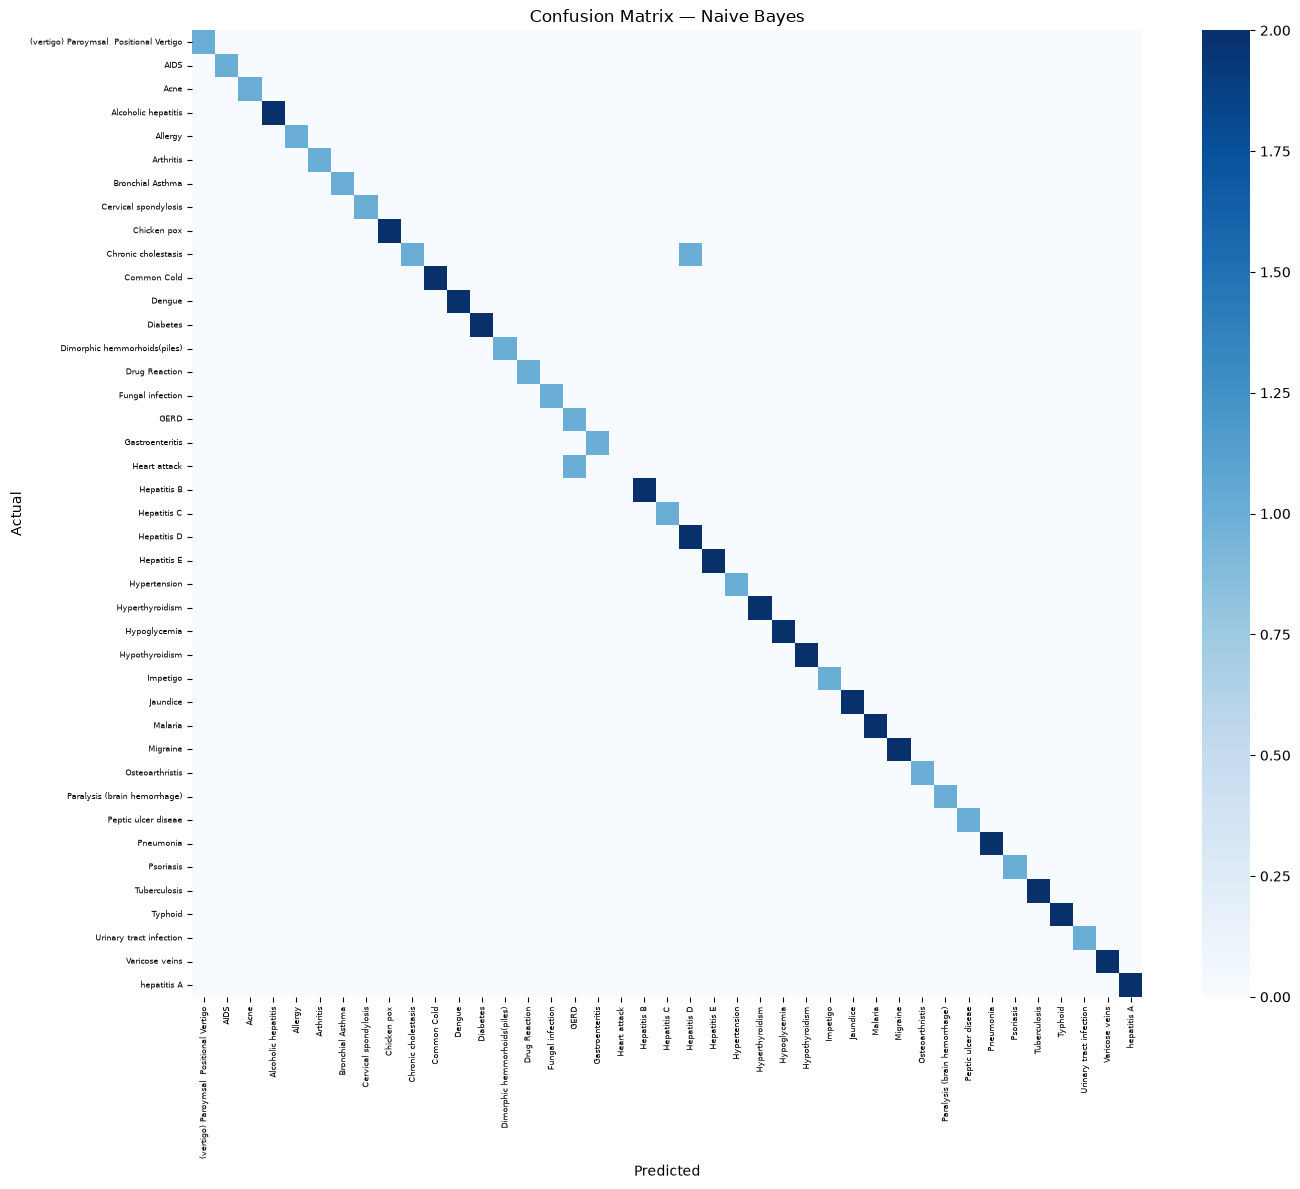

In [12]:
# --- Confusion matrices (one heatmap per model) ---
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0, fontsize=6)
    plt.tight_layout()
    plt.show()

## 6. Select & Export the Best Model

Selection is based on **macro recall** rather than raw accuracy. In a medical triage
context, missing a rarer disease (false negative) is more costly than a small drop in
overall accuracy, so we prioritize the model that best identifies every class, not
just the common ones.


In [13]:
best_name = max(results, key=lambda n: results[n]["macro_recall"])
best_model = results[best_name]["model"]

print(f"Best model: {best_name}")
print(f"  Accuracy:     {results[best_name]['accuracy']:.4f}")
print(f"  Macro Recall: {results[best_name]['macro_recall']:.4f}")

Best model: Random Forest
  Accuracy:     1.0000
  Macro Recall: 1.0000


In [14]:
# --- Export artifacts for the backend team ---
# best_disease_model.pkl : the trained sklearn model
# symptom_columns.pkl    : ordered list of binary feature names (input contract)
# label_encoder.pkl      : maps model's integer output back to disease names
#                          (not explicitly requested, but required to decode
#                          predictions -- without it best_disease_model.pkl's
#                          output is meaningless integers)

joblib.dump(best_model, "best_disease_model.pkl")
joblib.dump(symptom_columns, "symptom_columns.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Saved: best_disease_model.pkl, symptom_columns.pkl, label_encoder.pkl")

Saved: best_disease_model.pkl, symptom_columns.pkl, label_encoder.pkl


In [15]:
# --- Sanity check: reload and run one prediction end-to-end ---
loaded_model = joblib.load("best_disease_model.pkl")
loaded_columns = joblib.load("symptom_columns.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

sample = X_test.iloc[[0]]
pred_idx = loaded_model.predict(sample)[0]
pred_label = loaded_encoder.inverse_transform([pred_idx])[0]

# Differential diagnosis: top-3 probabilities (requires predict_proba, so
# skip gracefully for models that don't support it, e.g. plain DecisionTree
# still supports it, but keep this defensive for future model swaps).
if hasattr(loaded_model, "predict_proba"):
    proba = loaded_model.predict_proba(sample)[0]
    top3_idx = np.argsort(proba)[::-1][:3]
    top3 = [(loaded_encoder.inverse_transform([i])[0], round(proba[i] * 100, 1)) for i in top3_idx]
    print("Top-3 differential diagnosis:", top3)
else:
    print("Predicted:", pred_label)

Top-3 differential diagnosis: [('Hepatitis B', np.float64(74.0)), ('Chronic cholestasis', np.float64(8.0)), ('Hepatitis D', np.float64(6.5))]
